In [16]:
import sys
sys.path.append(r"c:/Users/Raees/Desktop/stuff/NuOscProbExact/src")

# Import modules
from oscprob2nu import *
from globaldefs import *
from hamiltonians2nu import *

In [17]:
import numpy as np 
import matplotlib.pyplot as plt
from NuOscProbExact.src import  oscprob2nu, globaldefs, hamiltonians2nu
import math
from scipy.stats import truncnorm
from scipy.optimize import curve_fit
import copy as cp

In [18]:
def gaus(x,p0,p1,p2):
    return p0 * math.e**((-0.5 * (x - p1)**2)/ p2**2)

def double_gaus(x, p0_left, p1_left, p2_left, p0_right, p1_right, p2_right):
    left_gaussian = p0_left * np.exp((-0.5 * (x - p1_left)**2) / p2_left ** 2)
    right_gaussian = p0_right * np.exp((-0.5 * (x - p1_right)**2) / p2_right ** 2)
    return left_gaussian + right_gaussian

# Function to generate counts from a Poisson distribution based on probabilities and Gaussian scaling    
def poisson_dist(probability, bin_centers, amplitude, mean, sigma):
    counts = np.random.poisson(probability * gaus(bin_centers,amplitude,mean,sigma)) 
    return counts

def poisson_dist_redo(probability, bin_centers, amplitude1, mean1, sigma1, amp2, mean2, sigma2):
    counts = np.random.poisson(probability * double_gaus(bin_centers,amplitude1,mean1,sigma1, amp2, mean2, sigma2)) 
    return counts


In [19]:
bin_centers = np.array([0.375, 0.875, 1.05, 1.15, 1.25, 1.35, 1.45, 1.55, 1.65, 1.75, 1.85, 1.95, 2.125, 2.375, 2.6375, 2.8875, 3.25, 3.75, 4.5])
bin_edges = np.array([0, 0.75, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.25, 2.5, 2.775, 3, 3.5, 4, 5])
counts_nd = np.array([2, 26, 46, 60, 78, 94, 110, 124, 136, 142, 144, 139, 120, 80, 48, 26, 10, 4, 0.5])
counts_fd = np.array([0, 3, 1, 3, 1, 2, 2, 4, 6, 9, 15, 12, 15.8, 10, 7, 9, 3.2, 2.8, 1.8])

# parameters
length_nd = 1 # [km]
length_fd = 810 # [km]
energy = 1e9

length_fd_redo = 810

In [20]:
def osc_probability_2nu(sector, case, length): 
    
    energy = 1e9 # Neutrino energy in eV

    # sector: '12' (solar mixing angle, mass squared diff), '23' (atmospheric mixing angle, mass squared diff)
    # case: vacuum, matter

    if sector == '12':
        mixing_angle = globaldefs.S12_NO_BF
        delta_mass_squared = globaldefs.D21_NO_BF
        label = ['Pee', 'Pem', 'Pme', 'Pmm']

    elif sector == '23':
        mixing_angle = globaldefs.S23_NO_BF
        delta_mass_squared = globaldefs.D31_NO_BF
        label = ['Pmm', 'Pmt', 'Ptm', 'Ptt']

    # Get the vacuum Hamiltonian
    h_vacuum_energy_indep = hamiltonians2nu.hamiltonian_2nu_vacuum_energy_independent(mixing_angle, delta_mass_squared)

    # Determine Hamiltonian based on case
    if case == 'vacuum':
        h = np.multiply(1./energy, h_vacuum_energy_indep)
    elif case == 'matter':
        h = hamiltonians2nu.hamiltonian_2nu_matter(h_vacuum_energy_indep, energy, globaldefs.VCC_EARTH_CRUST)

    # Calculate probabilities
    probabilities = oscprob2nu.probabilities_2nu(h, length * globaldefs.CONV_KM_TO_INV_EV)

    # Print each label with its corresponding probability
    for lbl, prob in zip(label, probabilities):
        print(f'{lbl}: {prob:.5f}')

    return probabilities

def plot_osc_2nu(sector, case, length, transition):
    # Calculate the oscillation probabilities based on the specified sector, case, and lengt
    probabilities = osc_probability_2nu(sector, case, length)

    # Determine the fitting parameters, weights and title
    if length == length_nd:
        popt = popt_nd
        weights1 = counts_nd
        title_text1 = 'Unoscillated vs Oscillated Neutrino Events in ND'
    elif length == length_fd:
        popt = popt_fd
        weights1 = counts_fd
        title_text1 = 'Unoscillated vs Oscillated Neutrino Events in FD'
    
    # Determine title (either matter or vacuum)
    if case == 'matter':
        title_text2 = 'In Matter'
    elif case == 'vacuum':
        title_text2 = 'In Vacuum'

    # Combine both parts of the title to create the full title
    full_title = f'{title_text1} {title_text2}'

    # Set labels and event index based on the transition type
    if transition == 'me':
        label1 = 'm --> e events'
        label2 = 'Gaussian (m --> e) events fit'
        index = 2
    elif transition == 'mt':
        index = 2
        label1 = 'm --> t events'
        label2 = 'Gaussian (m --> t) events fit'
    elif transition == 'mm':
        index = 0
        label1 = 'm --> m events'
        label2 = 'Gaussian (m --> m) events fit'

    # Calculate the Poisson-distributed counts for the oscillated events
    counts = poisson_dist(probabilities[index], bin_centers, *popt)

    # Fit a Gaussian to the oscillated counts
    popt_osc, _ = curve_fit(gaus, bin_edges[:-1], counts)
    
    # Start plotting
    plt.figure(figsize=(12,8))

    # Plot the histogram for unoscillated events
    plt.hist(bin_edges[:-1], bin_edges, weights=weights1, alpha=0.6, color='r', label='Unoscillated events')

    # Plot the Gaussian fit for unoscillated events
    plt.plot(x, gaus(x, *popt), color='green', label='Gaussian unoscillated events')

    # Plot the histogram for oscillated events with the calculated Poisson counts
    plt.hist(bin_edges[:-1], bins=bin_edges, weights=counts, density=False, alpha=0.6, color='b', label=label1)

    # Plot the Gaussian fit for oscillated events
    plt.plot(x, gaus(x, *popt_osc), color='black',label=label2)

    # Labels and title to the plot
    plt.xlabel('Energy (GeV)')
    plt.ylabel('Events')
    plt.title(full_title)
    plt.legend()
    plt.show()

[ 7.12516468  2.46257023 -0.76546697  9.36046216  1.93465063  0.20862763]
Fitted parameters for simulated ND events: Amplitude = 140.91490619526158, Mean = 1.749668477371812, Sigma = 0.507978228395975
Fitted parameters for simulated FD events: Amplitude = 13.614599944941599, Mean = 2.122052776518164, Sigma = 0.47007707592224474


Text(0.5, 0, 'Energy (GeV)')

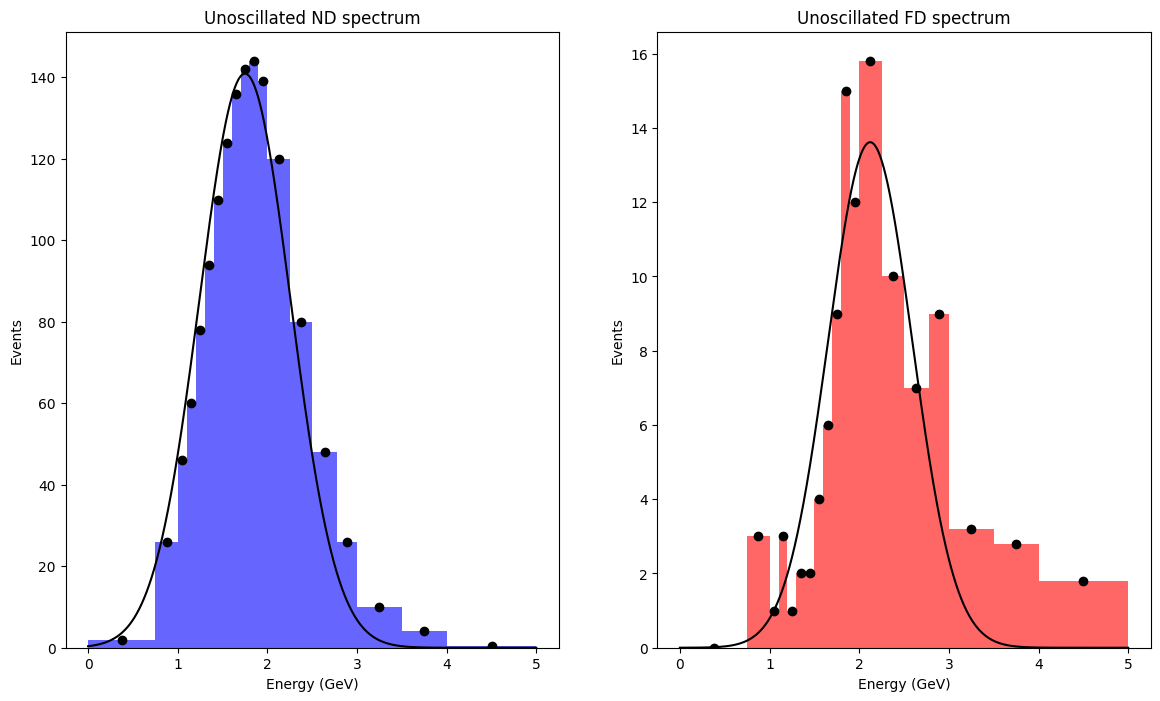

In [21]:
initial_guess_nd = [140,2,0.5]
initial_guess_fd = [8, 2, 0.5]

initial_guess_fd_redo = [5,1.2,0.5, 16,2.2,0.75]

popt_nd, _ = curve_fit(gaus, bin_edges[:-1], counts_nd, p0=initial_guess_nd)
popt_fd, _ = curve_fit(gaus, bin_edges[:-1], counts_fd, p0=initial_guess_fd)

popt_fd_redo, _ =curve_fit(double_gaus, bin_edges[:-1], counts_fd, p0=initial_guess_fd_redo)
print(popt_fd_redo)

print(f"Fitted parameters for simulated ND events: Amplitude = {popt_nd[0]}, Mean = {popt_nd[1]}, Sigma = {popt_nd[2]}")
print(f"Fitted parameters for simulated FD events: Amplitude = {popt_fd[0]}, Mean = {popt_fd[1]}, Sigma = {popt_fd[2]}")

fig, axs = plt.subplots(1, 2, figsize=(14, 8))

x = np.arange(0,5,0.001)

axs[0].hist(bin_edges[:-1],bin_edges ,weights=counts_nd, density=False, alpha=0.6, color='b')
axs[0].scatter(bin_centers, counts_nd, color='black')
axs[0].plot(x, gaus(x,*popt_nd), color='black')
axs[0].set_title("Unoscillated ND spectrum")
axs[0].set_ylabel("Events")
axs[0].set_xlabel("Energy (GeV)")

axs[1].hist(bin_edges[:-1], bin_edges,weights=counts_fd, density=False, alpha=0.6, color='r')
axs[1].scatter(bin_centers, counts_fd, color='black')
axs[1].plot(x, gaus(x, *popt_fd), color='black')
axs[1].set_title("Unoscillated FD spectrum")
axs[1].set_ylabel("Events")
axs[1].set_xlabel("Energy (GeV)")

plt.plot(x, double_gaus(x, *popt_fd_redo))

Pmm: 0.99999
Pmt: 0.00001
Ptm: 0.00001
Ptt: 0.99999


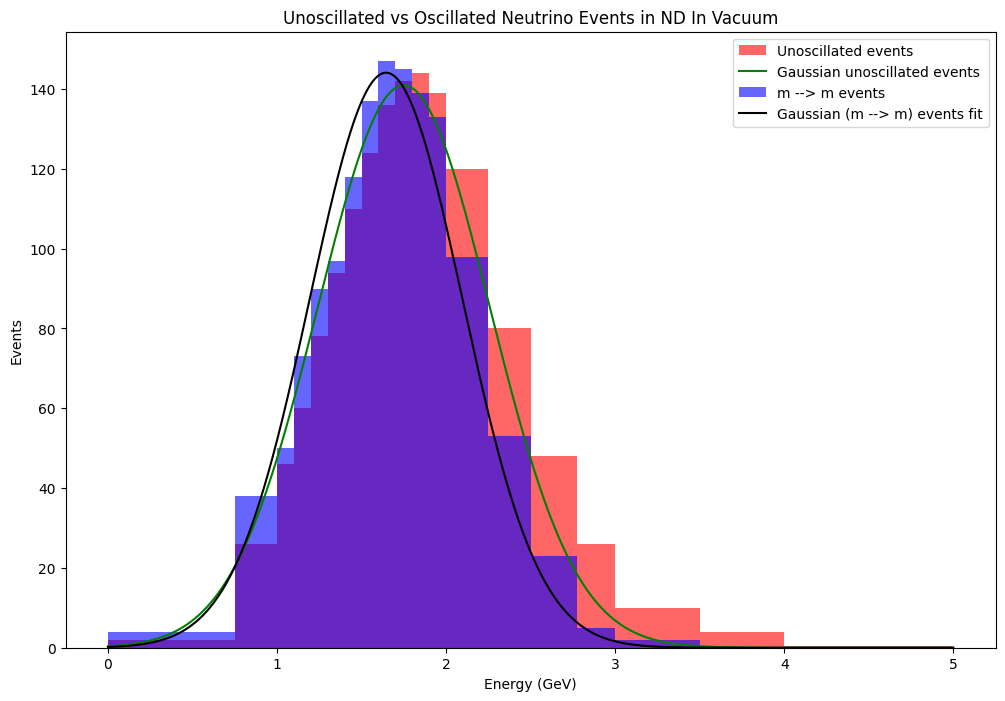

In [22]:
plot_osc_2nu(sector='23', case='vacuum', length=length_nd, transition='mm')

Pmm: 0.73380
Pmt: 0.26620
Ptm: 0.26620
Ptt: 0.73380


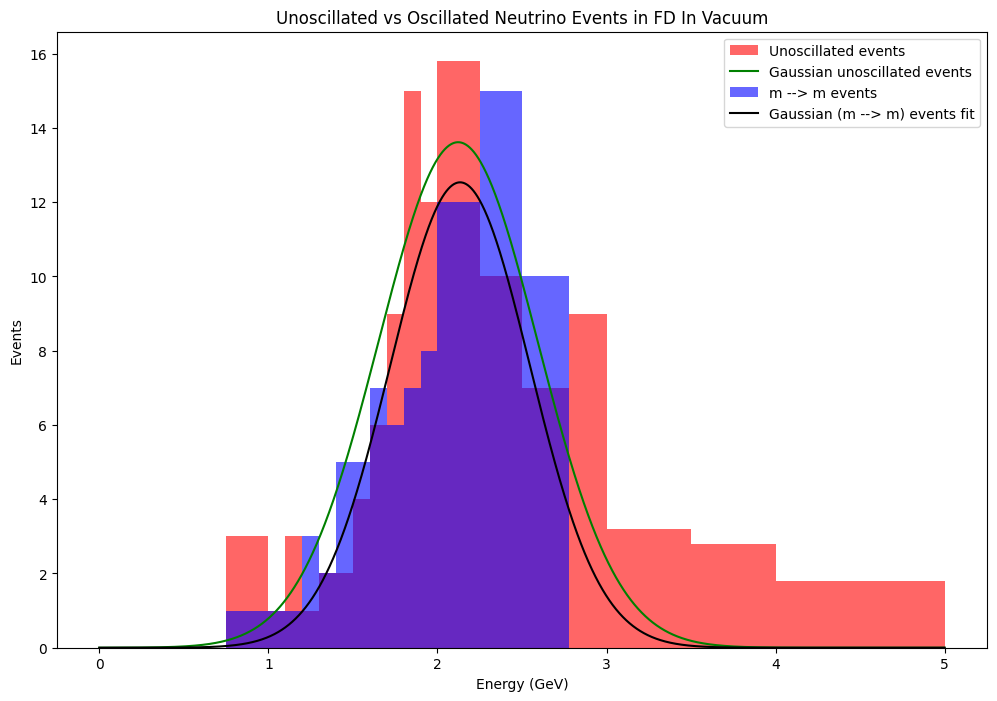

Pmm: 0.73380
Pmt: 0.26620
Ptm: 0.26620
Ptt: 0.73380


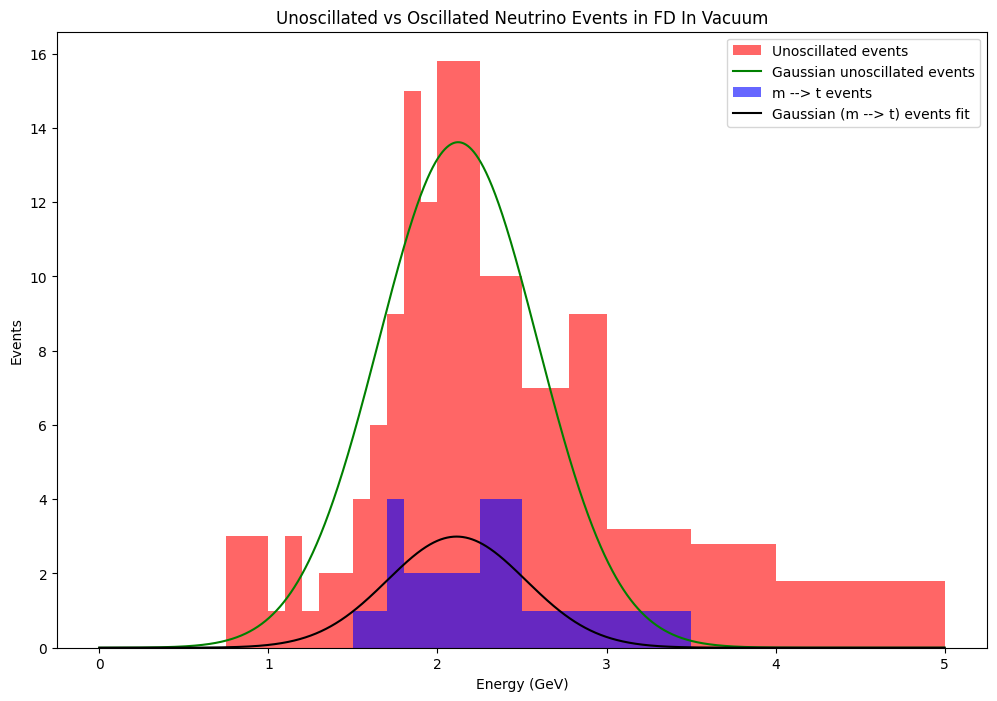

In [23]:
plot_osc_2nu(sector='23', case='vacuum', length=length_fd, transition='mm')
plot_osc_2nu(sector='23', case='vacuum', length=length_fd, transition='mt')

Pmm: 0.99999
Pmt: 0.00001
Ptm: 0.00001
Ptt: 0.99999


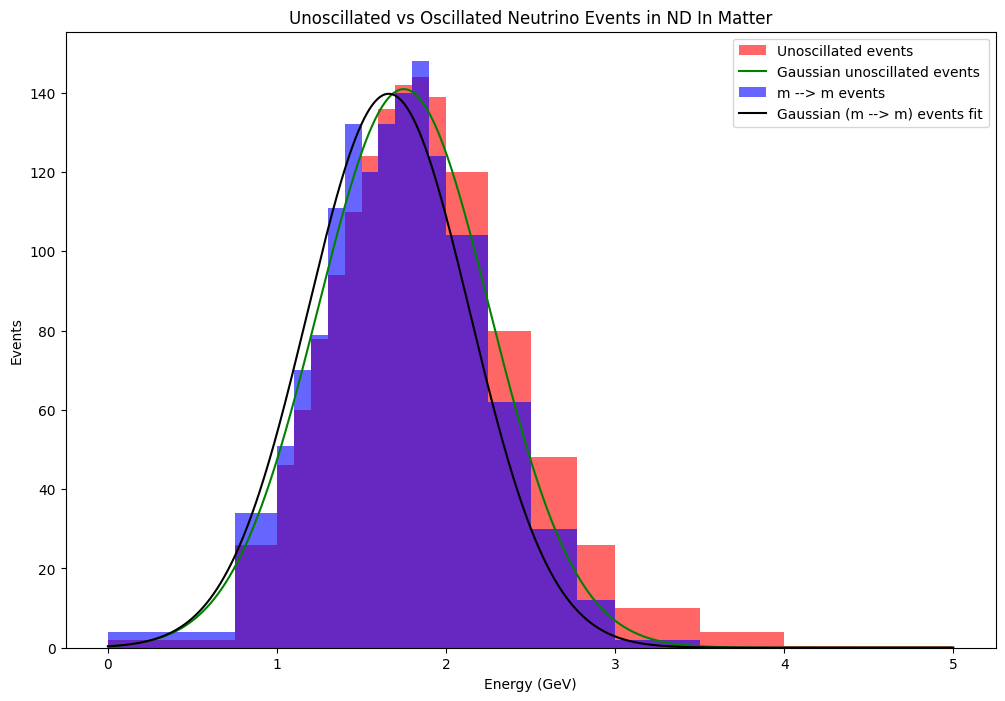

In [24]:
plot_osc_2nu(sector='23', case='matter', length=length_nd, transition='mm')

Pmm: 0.70291
Pmt: 0.29709
Ptm: 0.29709
Ptt: 0.70291


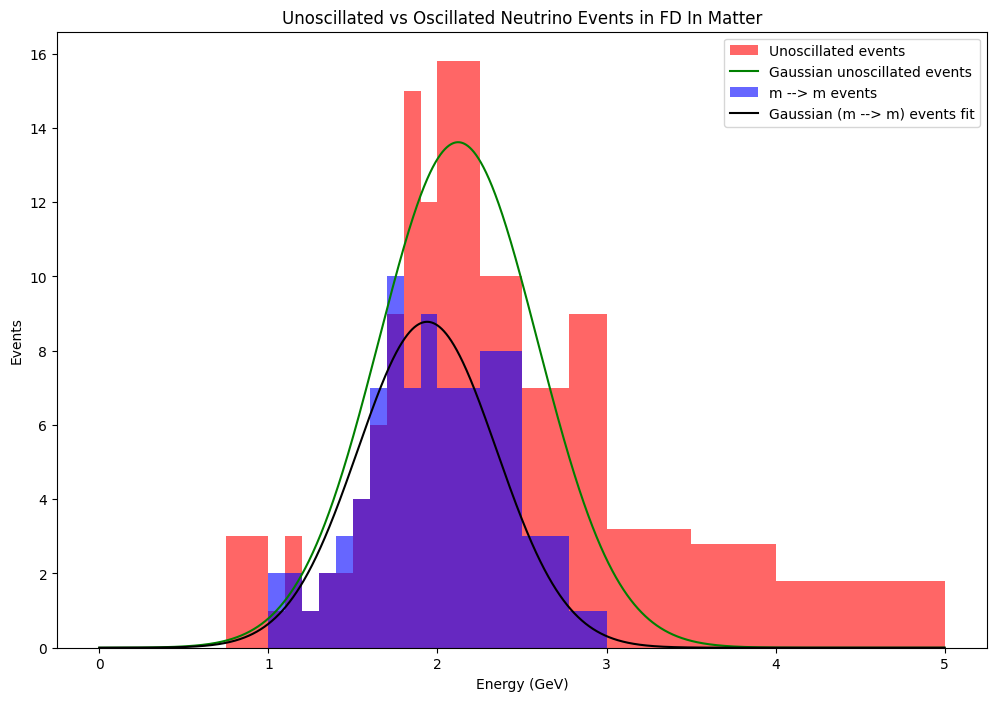

Pmm: 0.70291
Pmt: 0.29709
Ptm: 0.29709
Ptt: 0.70291


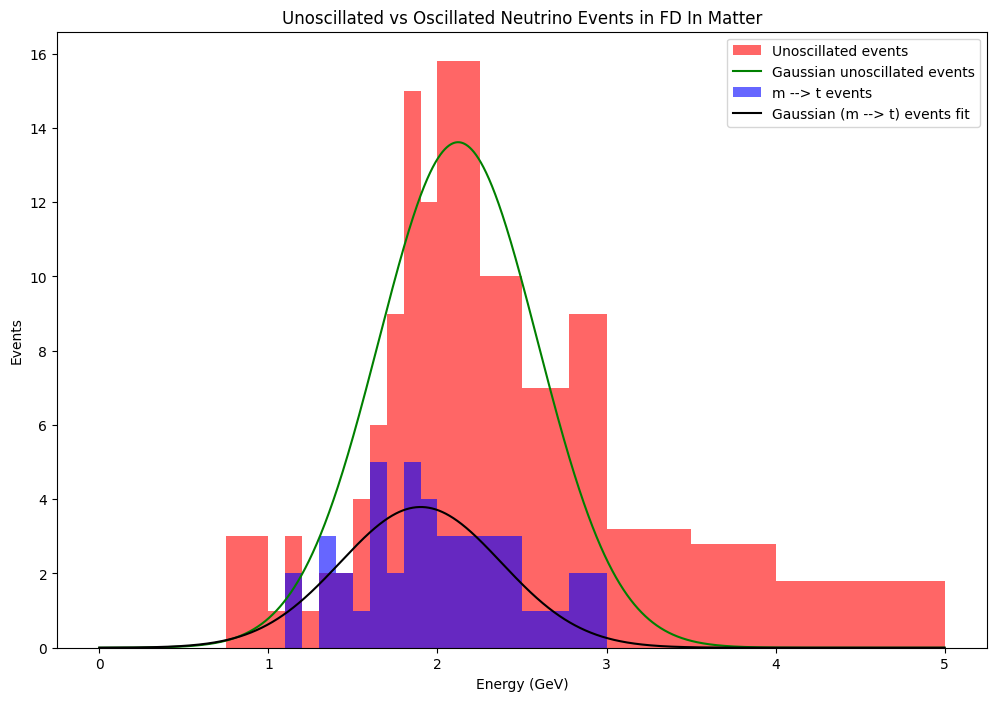

In [25]:
plot_osc_2nu(sector='23', case='matter', length=length_fd, transition='mm')
plot_osc_2nu(sector='23', case='matter', length=length_fd, transition='mt')

In [30]:
def plot_osc_2nu_fd(sector, case, transition):

    length = length_fd_redo
    probabilities = osc_probability_2nu(sector, case, length)

    if transition == 'me':
        label1 = 'm --> e events'
        label2 = 'Gaussian (m --> e) events fit'
        index = 2
    elif transition == 'mt':
        index = 2
        label1 = 'm --> t events'
        label2 = 'Gaussian (m --> t) events fit'
    elif transition == 'mm':
        index = 0
        label1 = 'm --> m events'
        label2 = 'Gaussian (m --> m) events fit'

    counts = poisson_dist_redo(probabilities[index], bin_centers, *popt_fd_redo)

    popt_osc, _ = curve_fit(double_gaus, bin_edges[:-1], counts)

    plt.figure(figsize=(12,8))
    plt.hist(bin_edges[:-1], bin_edges, weights=counts_fd, alpha=0.6, color='r', label='Unoscillated events')
    plt.plot(x, gaus(x, *popt_fd), color='green', label='Gaussian unoscillated events')
    plt.hist(bin_edges[:-1], bins=bin_edges, weights=counts, density=False, alpha=0.6, color='b', label=label1)
    plt.plot(x, double_gaus(x, *popt_osc), color='black',label=label2)
    plt.xlabel('Energy (GeV)')
    plt.ylabel('Events')
    plt.title('Unoscillated vs Oscillated Neutrino Events in FD')
    plt.legend()
    plt.show()


Pmm: 0.70291
Pmt: 0.29709
Ptm: 0.29709
Ptt: 0.70291


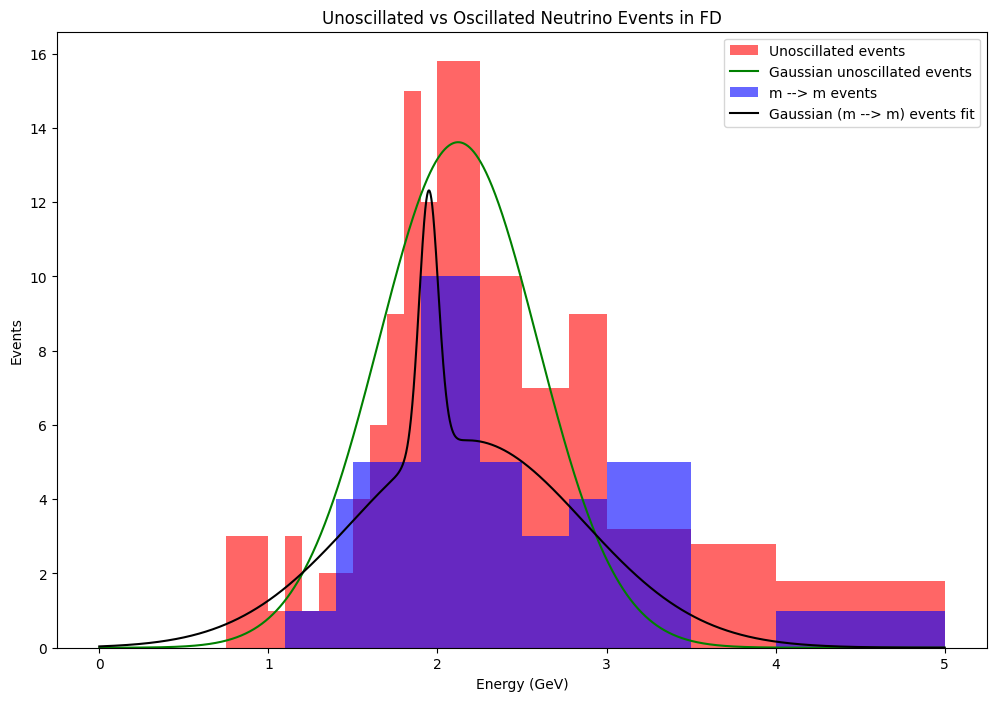

In [31]:
plot_osc_2nu_fd(sector='23', case='matter', transition='mm')